# 05 — Frozen-model distribution-shift robustness
Fit each model once on the common unshifted development sample, then evaluate the same fitted parameters across a paired severity curve. The current DGP stress jointly increases innovation scale and common correlation; isolated shift mechanisms belong in the later confirmatory study.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.experiments.stress import ShiftConfig, run_shift_curve
OUT = ROOT / 'results' / 'shift'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
SEVERITIES = [0.0, 0.25, 0.5, 0.75, 1.0]
curve = run_shift_curve(
    SEVERITIES,
    config=ShiftConfig(seed=505),
    training_config=TrainingConfig(epochs=120, patience=15, seed=505),
    lambda_cal=100.0,
    sequential_weight=2000.0,
)
display(curve)
curve.to_csv(OUT / 'frozen_shift_curve.csv', index=False)

,severity,model,model_index,lambda_cal,lambda_seq,nll,rmse,energy_score,coverage,interval_width,...,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks,delta_nll,delta_energy_score,delta_interval_score,delta_pit_calibration_error,delta_pit_mean_absolute_autocorrelation
0,0.00,RNN,0,0.0,0.0,5.198196,0.909415,1.202168,0.920833,3.218488,...,0.068001,0.057560,0.000844,0.069192,0.055770,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.00,BRNN,1,0.0,0.0,5.320461,0.916728,1.215469,0.919792,3.254873,...,0.064511,0.056068,0.000707,0.067376,0.059344,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.00,CA-RNN,2,100.0,2000.0,5.218812,0.909180,1.203922,0.933333,3.393729,...,0.073756,0.068837,0.001312,0.073440,0.068257,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.00,CA-BRNN,3,100.0,2000.0,5.396701,0.923917,1.227345,0.920833,3.379173,...,0.061155,0.059597,0.000980,0.065941,0.062431,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.25,RNN,0,0.0,0.0,6.023066,1.130419,1.488607,0.836458,3.216026,...,0.068344,0.062786,0.001142,0.067634,0.068070,0.824870,0.286438,1.027169,0.000139,0.000343
5,0.25,BRNN,1,0.0,0.0,6.194900,1.138747,1.501275,0.859375,3.307201,...,0.063594,0.063501,0.001075,0.062865,0.067415,0.874439,0.285807,0.944140,0.000272,-0.000917
6,0.25,CA-RNN,2,100.0,2000.0,5.963006,1.129479,1.481199,0.863542,3.389044,...,0.073641,0.051738,0.000765,0.070193,0.057510,0.744195,0.277276,0.901135,-0.000747,-0.000116
7,0.25,CA-BRNN,3,100.0,2000.0,6.244684,1.145756,1.508321,0.870833,3.454986,...,0.060487,0.060607,0.000888,0.063025,0.061302,0.847983,0.280976,0.934073,-0.000232,-0.000668
8,0.50,RNN,0,0.0,0.0,6.874994,1.349716,1.787948,0.768750,3.214091,...,0.069044,0.104605,0.003485,0.067048,0.108489,1.676798,0.585780,2.533687,0.002526,0.001043
9,0.50,BRNN,1,0.0,0.0,7.088931,1.360534,1.799158,0.780208,3.364391,...,0.063781,0.099556,0.003405,0.061898,0.101734,1.768470,0.583689,2.332508,0.002655,-0.000730


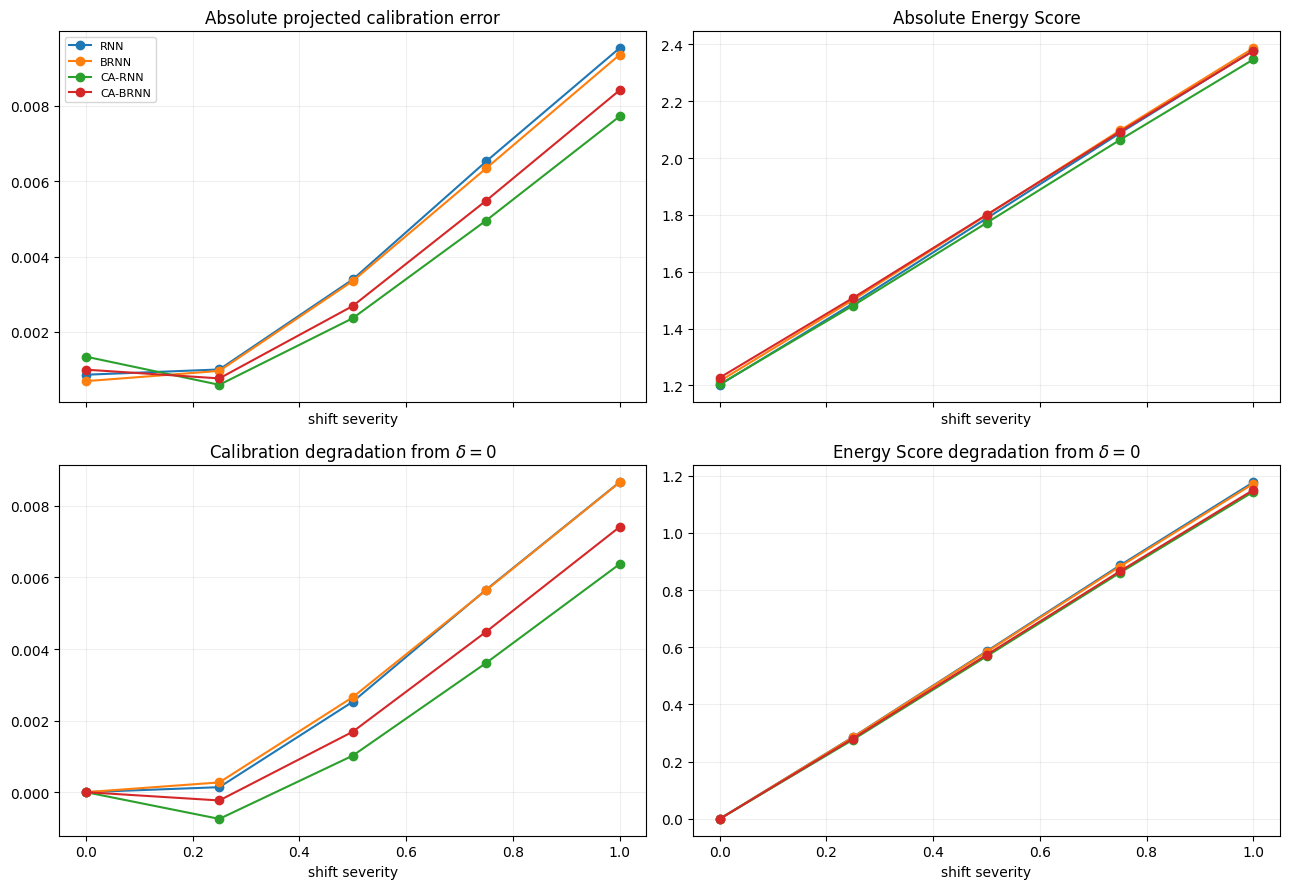

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for model, group in curve.groupby('model', sort=False):
    group = group.sort_values('severity')
    axes[0, 0].plot(group.severity, group.pit_calibration_error, marker='o', label=model)
    axes[0, 1].plot(group.severity, group.energy_score, marker='o', label=model)
    axes[1, 0].plot(group.severity, group.delta_pit_calibration_error, marker='o', label=model)
    axes[1, 1].plot(group.severity, group.delta_energy_score, marker='o', label=model)
axes[0, 0].set_title('Absolute projected calibration error')
axes[0, 1].set_title('Absolute Energy Score')
axes[1, 0].set_title(r'Calibration degradation from $\delta=0$')
axes[1, 1].set_title(r'Energy Score degradation from $\delta=0$')
for axis in axes.flat:
    axis.set_xlabel('shift severity')
    axis.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()

In [4]:
terminal = curve.loc[curve.severity.eq(max(SEVERITIES))].copy()
display(terminal[[
    'model', 'nll', 'energy_score', 'pit_calibration_error',
    'pit_mean_absolute_autocorrelation', 'delta_energy_score',
    'delta_pit_calibration_error'
]].sort_values('pit_calibration_error'))

,model,nll,energy_score,pit_calibration_error,pit_mean_absolute_autocorrelation,delta_energy_score,delta_pit_calibration_error
18,CA-RNN,8.127048,2.347387,0.007717,0.070788,1.143465,0.006372
19,CA-BRNN,8.519703,2.377112,0.008409,0.063630,1.149768,0.007410
17,BRNN,8.682833,2.387067,0.009350,0.068306,1.171599,0.008656
16,RNN,8.400846,2.378922,0.009528,0.068007,1.176754,0.008662


## Interpretation rules
Report both absolute performance and degradation from severity zero. A model is not robust merely because it starts from worse nominal performance and therefore deteriorates less. Treat this notebook as developmental: the combined scale/dependence stress, one DGP seed, and provisional regularization weights do not support confirmatory conclusions.